# CLASSIFICATION OF LONG BONE FRACTURE SEVERITY LEVELS USING DEEP LEARNING

This notebook implements a deep learning pipeline for classifying long bone X-ray images into three classes:

- Healthy bone
- Simple fracture
- Wedge/Complex fracture

The implementation includes:

- Dataset inspection and visualization
- Data preprocessing and augmentation
- A custom CNN model
- Model training and validation
- Testing and evaluation
- Performance comparison



#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q tensorflow pydot graphviz #Model Diagram

#Import Libraries

The following libraries are used for:

- deep learning: PyTorch and TorchVision
- numerical operations: NumPy
- plotting and visualization: Matplotlib and Seaborn
- image handling: PIL
- evaluation metrics: scikit-learn


In [ ]:
import os
import random
import math
import copy
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


# Reproducibility Setting

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset Path and Structure

In [ ]:
DATA_DIR = "/content/drive/MyDrive/fracture_project/data/all_original"

print("Dataset path:", DATA_DIR)
print("Folders found:", os.listdir(DATA_DIR))

Dataset path: /content/drive/MyDrive/fracture_project/data/all_original
Folders found: ['Simple', 'Wedge_Complex', 'Healthy']


In [ ]:
# Display number of images per class
class_counts = {}
supported_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        count = sum(
            1 for f in os.listdir(class_path)
            if f.lower().endswith(supported_ext)
        )
        class_counts[class_name] = count

print("Number of images per class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

print("Total images:", sum(class_counts.values()))

Number of images per class:
Healthy: 1203
Simple: 1211
Wedge_Complex: 1173
Total images: 3587


# Dataset Inspection and Visualization

In [ ]:
def get_image_paths_by_class(data_dir):
    image_paths = defaultdict(list)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.lower().endswith(supported_ext):
                    image_paths[class_name].append(os.path.join(class_path, fname))
    return image_paths

image_paths_by_class = get_image_paths_by_class(DATA_DIR)
list(image_paths_by_class.keys())

['Healthy', 'Simple', 'Wedge_Complex']

Show sample images from each class

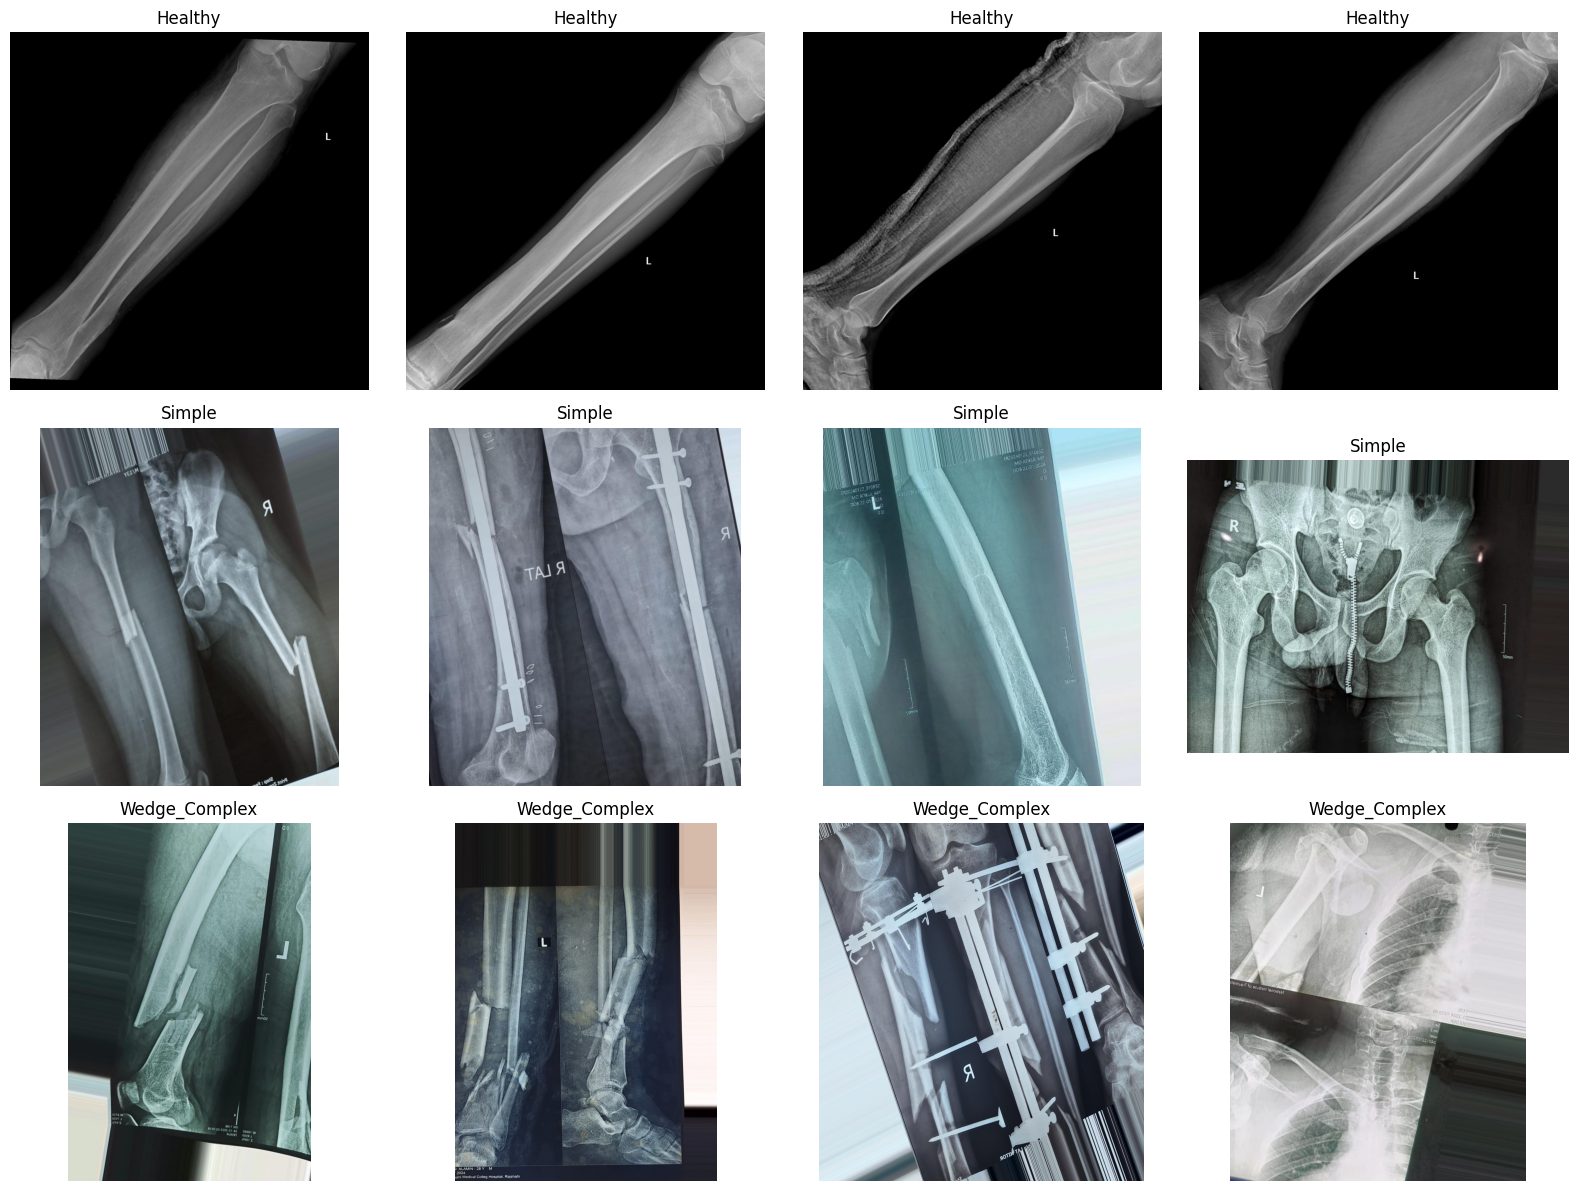

In [ ]:
def show_sample_images(image_paths_by_class, samples_per_class=4):
    classes = sorted(image_paths_by_class.keys())
    plt.figure(figsize=(4 * samples_per_class, 4 * len(classes)))

    plot_idx = 1
    for class_name in classes:
        samples = random.sample(
            image_paths_by_class[class_name],
            min(samples_per_class, len(image_paths_by_class[class_name]))
        )
        for img_path in samples:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(len(classes), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_sample_images(image_paths_by_class, samples_per_class=4)

Class distribution plot

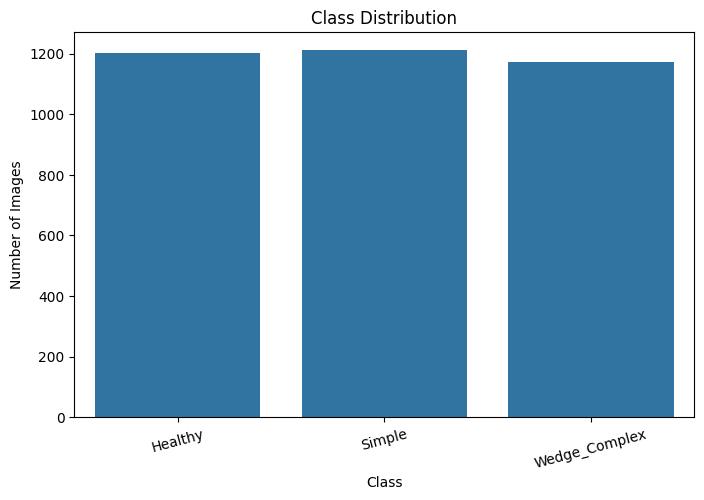

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()

# Data Preprocessing and Augmentation

The images are preprocessed before being fed into the neural network.

The preprocessing steps include:
- resizing images to 224 × 224
- converting images to tensors
- normalizing pixel values

Data augmentation is applied **only to the training set**.
This helps improve generalization by creating random variations of training images.

Augmentation methods used:
- random resized crop
- random horizontal flip
- random rotation
- brightness/contrast adjustment

Validation and test images are not augmented.

In [ ]:
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3
EPOCHS = 50
PATIENCE = 10
MIN_DELTA = 0.0001
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create Train/Validation/Test Splits

The dataset is split into:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

The same split is used for all models to ensure fair comparison.

In [ ]:
base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes

print("Class names:", class_names)
print("Class to index mapping:", base_dataset.class_to_idx)
print("Total images:", len(base_dataset))

Class names: ['Healthy', 'Simple', 'Wedge_Complex']
Class to index mapping: {'Healthy': 0, 'Simple': 1, 'Wedge_Complex': 2}
Total images: 3587


In [ ]:
total_size = len(base_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

indices = list(range(total_size))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

print("Train size:", len(train_indices))
print("Validation size:", len(val_indices))
print("Test size:", len(test_indices))

Train size: 2510
Validation size: 538
Test size: 539


In [ ]:
# Create two datasets with different transforms
train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(eval_dataset_full, val_indices)
test_dataset = Subset(eval_dataset_full, test_indices)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders created successfully.")

DataLoaders created successfully.


# Denormalization Helper for Visualization

Images are normalized before training; hence, they are denormalized before displaying them.
The following helper function converts tensors back into displayable image format.

In [ ]:
def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

Device Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Custom CNN Model Architecture

A custom Convolutional Neural Network (CNN) was designed to classify long bone X-ray images into three fracture severity categories:

- Healthy bone  
- Simple fracture  
- Wedge/Complex fracture  

The model processes input images of size **224 × 224** and learns hierarchical visual features that help distinguish between normal bone structure and different fracture patterns.

### Architecture Design

The custom CNN consists of several convolutional blocks that progressively extract features from the X-ray images. Each block includes:

- **Convolution layers** to learn spatial features from the images  
- **Batch Normalization** to stabilize and accelerate training  
- **ReLU activation** to introduce non-linearity  
- **Max Pooling** to reduce spatial dimensions and retain important features  

As the network depth increases, the number of feature channels increases, allowing the model to learn more complex fracture-related patterns.

After feature extraction, the resulting feature maps are flattened and passed through **fully connected layers** for classification. A **Dropout layer** is used before the final layer to reduce overfitting.

### Output Layer

The final layer contains **three neurons**, corresponding to the three fracture classes.

The model is trained using **CrossEntropyLoss** and optimized using the **Adam optimizer**.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#Loss Function, Optimizer, and Training Utilities

All models are trained using the same pipeline:

- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Number of epochs: 40

During training, the following are tracked:
- training loss
- validation loss
- training accuracy
- validation accuracy

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

In [ ]:
def calculate_epoch_metrics(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct, total = calculate_epoch_metrics(outputs, labels)
        running_correct += correct
        running_total += total

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            correct, total = calculate_epoch_metrics(outputs, labels)
            running_correct += correct
            running_total += total

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=50, patience=5, min_delta=0.0001):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 50)

        # Early stopping based on validation loss
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter}/{patience}")

       # if patience_counter >= patience:
        #    print("Stopping early to prevent overfitting.")
         #   break

    model.load_state_dict(best_model_wts)
    return model, history

#Train custom CNN

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/fracture_project/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Models will be saved to:", SAVE_DIR)

Models will be saved to: /content/drive/MyDrive/fracture_project/saved_models


In [ ]:
trained_models = {}
training_histories = {}
model_test_results = {}

model_name = "CustomCNN"
print(f"\nTraining model: {model_name}")

model = CustomCNN(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA
)

trained_models[model_name] = model
training_histories[model_name] = history

save_path = os.path.join(SAVE_DIR, f"{model_name}_model.pth")
torch.save(model.state_dict(), save_path)

print(f"{model_name} saved at {save_path}")


Training model: CustomCNN
Epoch 1/50
Train Loss: 0.8975 | Train Acc: 0.6789
Val Loss:   0.5204 | Val Acc:   0.7788
--------------------------------------------------
Epoch 2/50
Train Loss: 0.5386 | Train Acc: 0.7562
Val Loss:   0.5690 | Val Acc:   0.7138
--------------------------------------------------
EarlyStopping counter: 1/10
Epoch 3/50
Train Loss: 0.5150 | Train Acc: 0.7602
Val Loss:   0.5007 | Val Acc:   0.7900
--------------------------------------------------
Epoch 4/50
Train Loss: 0.5027 | Train Acc: 0.7713
Val Loss:   0.5007 | Val Acc:   0.7584
--------------------------------------------------
EarlyStopping counter: 1/10
Epoch 5/50
Train Loss: 0.5036 | Train Acc: 0.7729
Val Loss:   0.4670 | Val Acc:   0.7993
--------------------------------------------------
Epoch 6/50
Train Loss: 0.4766 | Train Acc: 0.7849
Val Loss:   0.4579 | Val Acc:   0.8011
--------------------------------------------------
Epoch 7/50
Train Loss: 0.4854 | Train Acc: 0.7865
Val Loss:   0.4561 | Val Ac

# Visualization of Training Results

For each model, the following plots are displayed:
- training accuracy vs validation accuracy
- training loss vs validation loss


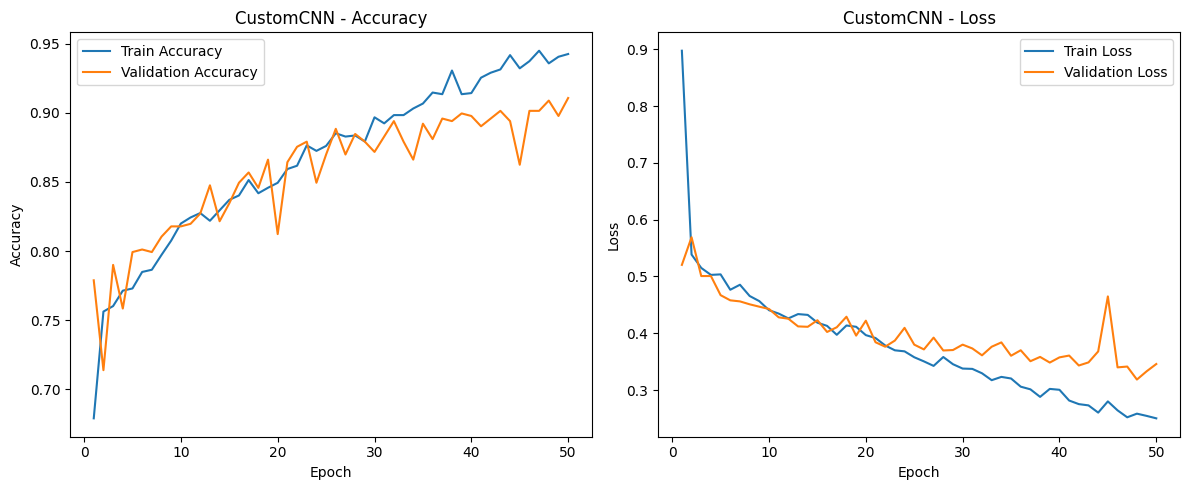

In [ ]:
def plot_training_history(history, model_name):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

for model_name, history in training_histories.items():
    plot_training_history(history, model_name)

# Test Evaluation Metrics

Each trained model is evaluated on the unseen test dataset.

The following metrics are computed:
- Accuracy
- Precision
- Recall
- F1-score

In [ ]:
def evaluate_model_on_test(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

In [ ]:
for model_name, model in trained_models.items():
    results = evaluate_model_on_test(model, test_loader, device)
    model_test_results[model_name] = results

    print(f"\nTest Results - {model_name}")
    print(f"Accuracy : {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall   : {results['recall']:.4f}")
    print(f"F1 Score : {results['f1']:.4f}")


Test Results - CustomCNN
Accuracy : 0.9054
Precision: 0.9051
Recall   : 0.9054
F1 Score : 0.9053


# Confusion Matrix

A confusion matrix is used to analyze classification performance class by class.

Rows represent the true labels.  
Columns represent the predicted labels.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for model_name, results in model_test_results.items():
    plot_confusion_matrix(results["confusion_matrix"], class_names, f"Confusion Matrix - {model_name}")

#CNN Model Diagram

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Input
from tensorflow.keras.utils import plot_model

model = Sequential()
model.add(Input(shape=(224,224,3)))

model.add(Conv2D(32, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(3, activation='softmax'))

plot_model(model, to_file='custom_cnn_architecture.png', show_shapes=True)

from IPython.display import Image, display
display(Image('custom_cnn_architecture.png'))

# Classification Report

In [ ]:
for model_name, results in model_test_results.items():
    print(f"\nClassification Report - {model_name}")
    print(classification_report(results["labels"], results["preds"], target_names=class_names, zero_division=0))


Classification Report - CustomCNN
               precision    recall  f1-score   support

      Healthy       0.99      0.99      0.99       173
       Simple       0.87      0.87      0.87       184
Wedge_Complex       0.86      0.86      0.86       182

     accuracy                           0.91       539
    macro avg       0.91      0.91      0.91       539
 weighted avg       0.91      0.91      0.91       539

